# Food Bank Combined Data EDA
## Setup: imports, load, datetime conversion

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

agency  = pd.read_csv('../clean_data/combined_agency.csv')
monthly = pd.read_csv('../clean_data/combined_monthly.csv')

print("agency:", agency.shape)
print("monthly:", monthly.shape)
agency.head()

monthly['month'] = pd.to_datetime(monthly['month'])
monthly = monthly.sort_values('month').reset_index(drop=True)


agency: (4491, 22)
monthly: (138, 13)


## Data quality: Homelessness columns are mostly missing

In [21]:
print("Rows total:", len(monthly))
print("total_homeless non-null:", monthly['total_homeless'].notna().sum())
print("total_chronic_homeless non-null:", monthly['total_chronic_homeless'].notna().sum())
print("Date range:", monthly['month'].min(), "→", monthly['month'].max())

Rows total: 138
total_homeless non-null: 90
total_chronic_homeless non-null: 90
Date range: 2015-01-01 00:00:00 → 2026-06-01 00:00:00


## 1. Overview of the demand metrics
Summary stats for the food bank columns: ranges, central values, and any red flags (negatives, impossible values).

In [22]:
demand_cols = ['total_visits','total_people_served','unique_clients',
               'unique_households','avg_household_size','avg_client_age']
monthly[demand_cols].describe()

,total_visits,total_people_served,unique_clients,unique_households,avg_household_size,avg_client_age
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,9722.456522,28818.007246,5692.239130,5480.268116,2.683532,44.280110
std,4702.396536,15560.480999,2405.255373,2311.049367,0.281664,1.120654
min,1864.000000,2205.000000,1327.000000,1305.000000,1.256705,41.663246
25%,5908.000000,16362.250000,3866.000000,3750.750000,2.563626,43.493026
50%,7428.000000,22516.000000,4322.500000,4159.500000,2.734612,44.264766
75%,14755.750000,43053.000000,8544.250000,8229.750000,2.865312,45.144878
max,18958.000000,60647.000000,10357.000000,9968.000000,3.090081,46.439793


## 2. Trends over time
How food bank demand has moved from 2015 to 2026. Raw series + 12-month rolling average to see the underlying direction.

In [39]:
# numeric summary of the trend: first vs last year averages
monthly['year'] = monthly['month'].dt.year
yearly = monthly.groupby('year')['total_visits'].mean()
print("Average monthly visits by year:\n", yearly.round(0))

agency['month'] = pd.to_datetime(agency['month'])
print(agency.groupby(agency['month'].dt.year)['visited_agency'].nunique())

per_agency = agency.groupby(agency['month'].dt.year)['total_visits'].sum() / \
             agency.groupby(agency['month'].dt.year)['visited_agency'].nunique()
print(per_agency.round(0).to_string())

first = per_agency.loc[2015]
last_full = per_agency.loc[2025]
print("Per-agency growth 2015→2025:", round((last_full/first - 1)*100, 1), "%")

Average monthly visits by year:
 year
2015     4566.0
2016     5874.0
2017     5943.0
2018     5921.0
2019     6228.0
2020     7265.0
2021     9120.0
2022    10283.0
2023    14215.0
2024    16323.0
2025    17268.0
2026    17604.0
Name: total_visits, dtype: float64
month
2015    28
2016    32
2017    32
2018    31
2019    33
2020    38
2021    33
2022    42
2023    43
2024    48
2025    49
2026    51
Name: visited_agency, dtype: int64
month
2015    1957.0
2016    2203.0
2017    2229.0
2018    2292.0
2019    2265.0
2020    2294.0
2021    3316.0
2022    2938.0
2023    3967.0
2024    4081.0
2025    4229.0
2026    2071.0
Per-agency growth 2015→2025: 116.1 %


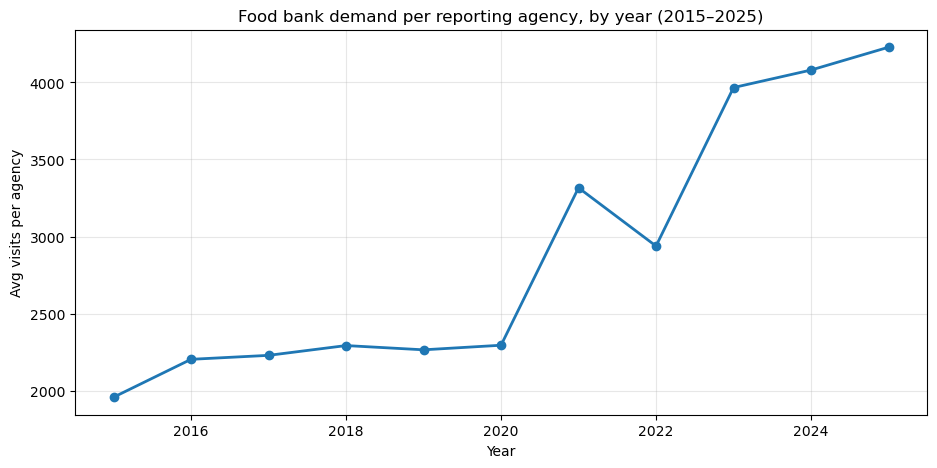

In [47]:
#visualization
# per-agency demand by year (coverage-adjusted)
per_agency = (agency.groupby(agency['month'].dt.year)['total_visits'].sum() /
              agency.groupby(agency['month'].dt.year)['visited_agency'].nunique())

# exclude partial 2026 from the yearly view
per_agency_full = per_agency[per_agency.index <= 2025]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(per_agency_full.index, per_agency_full.values, marker='o', linewidth=2)
ax.set_title('Food bank demand per reporting agency, by year (2015–2025)')
ax.set_xlabel('Year'); ax.set_ylabel('Avg visits per agency')
ax.grid(alpha=0.3)
plt.show()

### Writeup
Food bank demand rose substantially over the period, but raw total visits overstate it: reporting agencies grew from 28 (2015) to 51 (2025), so totals rose partly through wider coverage, not just demand. Measured per agency, demand grew ~116% from 2015 to 2025, which is real and significant, but less than half what raw totals imply. Demand was relatively flat from 2015-2020, then rose sharply in 2021 (likely pandemic-related), dipped somewhat in 2022, and climbed steadily from 2023 onward (possibly reflecting cost-of-living pressures). The bulk of the growth is concentrated in the post-2020 period.

## 3. Seasonality
Is there a repeating within-year pattern? Averaging each calendar month across all years separates seasonality from the long-run trend.

In [43]:
monthly['month_num'] = monthly['month'].dt.month
seasonal = monthly.groupby('month_num')['total_visits'].mean()
print("Avg visits by calendar month:\n", seasonal.round(0))
print("\nPeak month:", seasonal.idxmax(), "| Low month:", seasonal.idxmin())
print("Peak-to-trough swing:", round((seasonal.max()/seasonal.min()-1)*100,1), "%")
print(agency.groupby(agency['month'].dt.month)['visited_agency'].nunique())

Avg visits by calendar month:
 month_num
1      8975.0
2      8929.0
3     10264.0
4      9935.0
5     10384.0
6     10357.0
7      9196.0
8      9685.0
9      9558.0
10    10130.0
11    10566.0
12     8645.0
Name: total_visits, dtype: float64

Peak month: 11 | Low month: 12
Peak-to-trough swing: 22.2 %
month
1     57
2     57
3     59
4     59
5     58
6     58
7     53
8     53
9     53
10    56
11    56
12    58
Name: visited_agency, dtype: int64


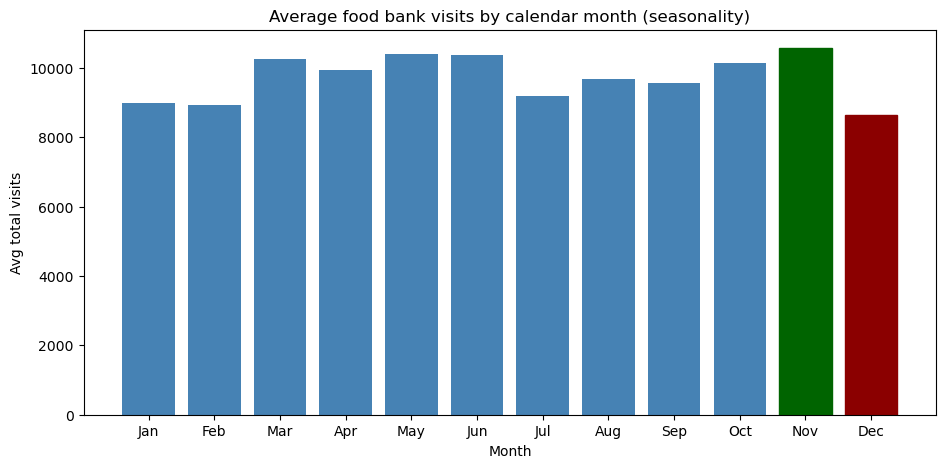

In [48]:
#visualization
monthly['month_num'] = monthly['month'].dt.month
seasonal = monthly.groupby('month_num')['total_visits'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(1, 13), seasonal.values, color='steelblue')
# highlight peak and trough
bars[seasonal.values.argmax()].set_color('darkgreen')
bars[seasonal.values.argmin()].set_color('darkred')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.set_title('Average food bank visits by calendar month (seasonality)')
ax.set_xlabel('Month'); ax.set_ylabel('Avg total visits')
plt.show()

### Writeup
Food bank demand shows mild seasonality. Most months cluster fairly closely (~9,000–10,600 avg visits), with a gentle tendency toward higher demand in spring and fall (March, May–June, October–November) and lower demand in mid-summer (July) and especially December. November is the single highest month and December the lowest, a ~22% gap, but the overall pattern is a shallow wave rather than sharp peaks. Reporting coverage is consistent across all months (56–59 agencies each), so the December low reflects genuine lower demand, not a reporting gap, possibly the effect of alternative food sources and charitable support over the holidays. Seasonality is worth including in modeling but is a relatively weak effect.

## 4. Source of income: Ontario Works vs ODSP
Trends in the two income-support programs, and whether they move together or diverge.

In [31]:
income_cols = ['ow_cases_official','ow_beneficiaries',
               'odsp_cases_official','odsp_beneficiaries']
print(monthly.groupby('year')[income_cols].mean().round(0))

print(monthly[['total_visits','ow_beneficiaries','odsp_beneficiaries',
               'ow_cases_official','odsp_cases_official']].corr()['total_visits'].round(2))

      ow_cases_official  ow_beneficiaries  odsp_cases_official  \
year                                                             
2015             8424.0           15255.0              11098.0   
2016             8643.0           15478.0              11428.0   
2017             9092.0           16960.0              11927.0   
2018             9245.0           17676.0              12438.0   
2019             9138.0           17460.0              12829.0   
2020             8833.0           17048.0              12899.0   
2021             7474.0           14557.0              12799.0   
2022             7918.0           14839.0              12770.0   
2023             8442.0           15384.0              12811.0   
2024             9492.0           16752.0              13068.0   
2025            10496.0           18202.0              13422.0   
2026            10804.0           18619.0              13590.0   

      odsp_beneficiaries  
year                      
2015             1516

### Writeup
OW and ODSP show distinct patterns. OW caseloads and beneficiaries both dipped around 2020-21, likely reflecting pandemic-era federal benefits (e.g. CERB) temporarily reducing provincial assistance, then resumed growth. ODSP was comparatively flat from ~2018-2024 with a gradual upward trend. The two programs diverge rather than move in lockstep, which makes sense given they serve different populations (general vs disability support). ODSP has a stronger association with food bank demand (correlation ~0.70–0.74) than OW (~0.47), making ODSP the more promising predictor of the two income-support measures.

## 5. Relationships: do income & demand move together?
Correlation between demand and income-support indicators

In [26]:
rel_cols = ['total_visits','total_people_served',
            'ow_beneficiaries','odsp_beneficiaries']
print(monthly[rel_cols].corr().round(2))

                     total_visits  total_people_served  ow_beneficiaries  \
total_visits                 1.00                 1.00              0.25   
total_people_served          1.00                 1.00              0.27   
ow_beneficiaries             0.25                 0.27              1.00   
odsp_beneficiaries           0.70                 0.73              0.41   

                     odsp_beneficiaries  
total_visits                       0.70  
total_people_served                0.73  
ow_beneficiaries                   0.41  
odsp_beneficiaries                 1.00  


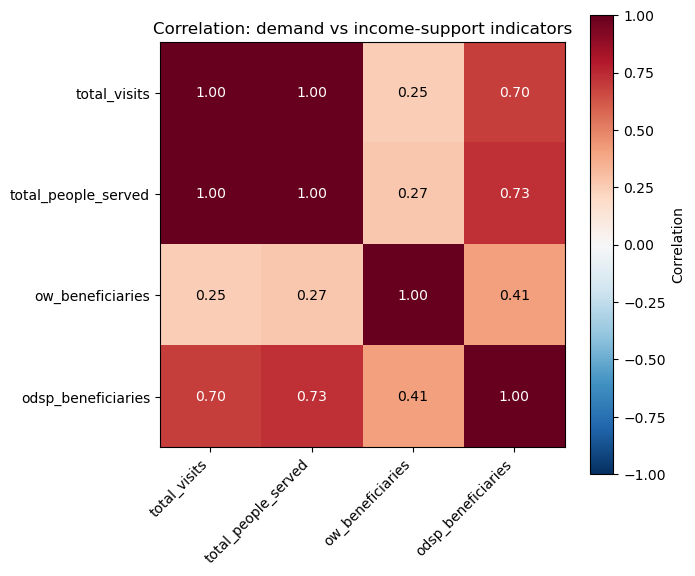

In [49]:
#visualization
rel_cols = ['total_visits','total_people_served','ow_beneficiaries','odsp_beneficiaries']
corr = monthly[rel_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(rel_cols))); ax.set_xticklabels(rel_cols, rotation=45, ha='right')
ax.set_yticks(range(len(rel_cols))); ax.set_yticklabels(rel_cols)
# annotate each cell with its value
for i in range(len(rel_cols)):
    for j in range(len(rel_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i,j])>0.5 else 'black')
fig.colorbar(im, label='Correlation')
ax.set_title('Correlation: demand vs income-support indicators')
plt.tight_layout()
plt.show()

### Writeup
Food bank demand (total_visits) is moderately correlated with ODSP beneficiaries (0.70) but only weakly with OW beneficiaries (0.25), reinforcing ODSP as the stronger demand-related indicator. total_visits and total_people_served are perfectly correlated (1.00) and they carry the same information, so only one should be used in modeling. OW and ODSP correlate mildly with each other (0.41), distinct enough to retain both as features if desired. For modeling: use a single demand measure (visits or people_served, not both); prioritize ODSP over OW as a predictor.

## 6. Region / agency breakdown (agency file)
Switching to the finer-grained agency data to see which agencies drive the totals and whether they behave differently.

In [44]:
# how many agencies, and how consistent is their reporting?
print("Unique agencies:", agency['visited_agency'].nunique())
print("Months covered:", agency['month'].nunique())
print("Rows:", len(agency), "(if agencies reported every month, expect ~agencies × months)\n")

# which agencies dominate total volume?
by_agency = agency.groupby('visited_agency')['total_visits'].agg(['sum','mean','count'])
by_agency = by_agency.sort_values('sum', ascending=False)
print("Top agencies by total visits:\n", by_agency.head(10))
print("\nReporting consistency — 'count' = months each agency appears.")
print("Agencies appearing in every month:", (by_agency['count'] == agency['month'].nunique()).sum())

Unique agencies: 61
Months covered: 138
Rows: 4491 (if agencies reported every month, expect ~agencies × months)

Top agencies by total visits:
                                                        sum         mean  count
visited_agency                                                                
Emergency Food Hamper Program - House of Friend...  346123  2526.445255    137
Cambridge Food Bank - Cambridge                     178043  1290.166667    138
Kingsdale Community Centre - Neighbourhood Food...   83161   607.014599    137
Chandler Mowat Community Centre - Neighbourhood...   78134   601.030769    130
Sunnydale Community Centre - Neighbourhood Food...   54380   408.872180    133
Woolwich Community Services                          48293   355.095588    136
Centreville Chicopee Community Centre - Neighbo...   48057   624.116883     77
Victoria Hills - House of Friendship                 44223   680.353846     65
Ray of Hope                                          41224   305.

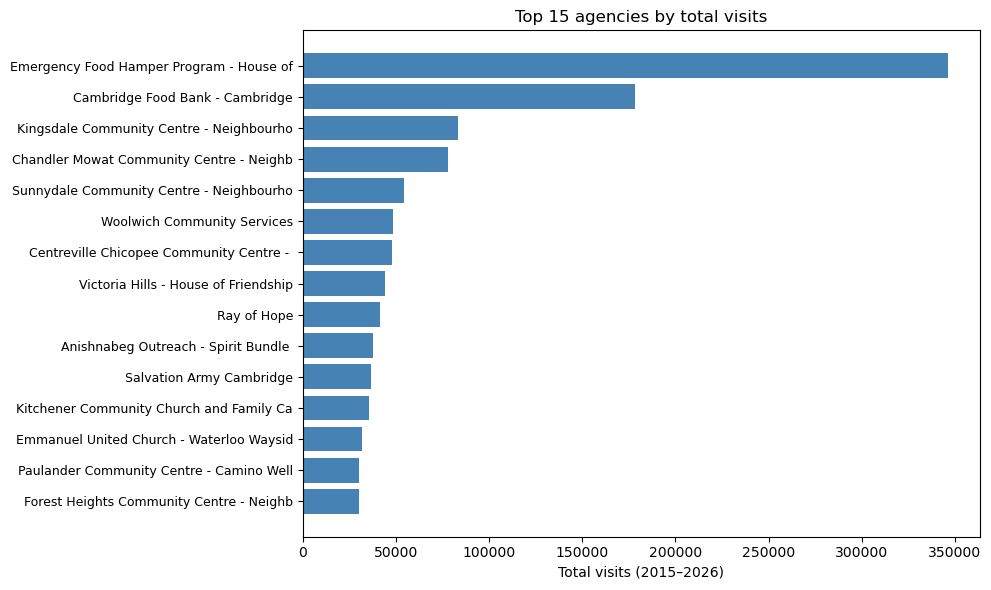

Top 5 agencies = 55.1 % of all visits
Top 1 agency   = 25.8 % of all visits


In [50]:
by_agency = agency.groupby('visited_agency')['total_visits'].sum().sort_values(ascending=False)

top_n = 15
top = by_agency.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top)), top.values, color='steelblue')
ax.set_yticks(range(len(top)))
# truncate long agency names so they fit
ax.set_yticklabels([name[:40] for name in top.index], fontsize=9)
ax.invert_yaxis()  # biggest at top
ax.set_title(f'Top {top_n} agencies by total visits')
ax.set_xlabel('Total visits (2015–2026)')
plt.tight_layout()
plt.show()

# print the concentration stat to pair with the chart
print("Top 5 agencies =", round(by_agency.head(5).sum()/by_agency.sum()*100,1), "% of all visits")
print("Top 1 agency   =", round(by_agency.head(1).sum()/by_agency.sum()*100,1), "% of all visits")

### Writeup
The data covers 61 agencies over 138 months, but reporting is highly inconsistent: only 1 agency reports in every month, meaning monthly totals sum a shifting set of agencies rather than a stable panel. Demand is also heavily concentrated because the top 5 agencies (of 61) account for 55.1% of all visits, and the single largest (Emergency Food Hamper Program) alone makes up 25.8%, roughly twice the next largest. For modeling, this combination is a key risk. Because coverage varies month to month and a few agencies dominate, raw monthly totals can shift based on which agencies reported rather than actual demand changes. This strongly reinforces using a per-agency or coverage-adjusted measure, and any sudden month-to-month movement should be checked against which agencies reported that month.

## 7. Client age demographics
Age-band breakdown of food bank clients. Which age groups dominate, and how much is unclassified ('Not Reported').

In [29]:
age_bands = ['0-17','18-30','31-44','45-64','65+','Not Reported']

# total clients per age band across all agencies/months
age_totals = agency[age_bands].sum().sort_values(ascending=False)
print("Total clients by age band:\n", age_totals.round(0))
print("\nShare of each band:")
print((age_totals / age_totals.sum() * 100).round(1))

# how much is unclassified?
print("\n'Not Reported' share:", round(agency['Not Reported'].sum()/agency[age_bands].sum().sum()*100,1), "%")

Total clients by age band:
 45-64           482834
31-44           464956
18-30           196289
65+             126060
Not Reported     66151
0-17              5409
dtype: int64

Share of each band:
45-64           36.0
31-44           34.7
18-30           14.6
65+              9.4
Not Reported     4.9
0-17             0.4
dtype: float64

'Not Reported' share: 4.9 %


### Write-up
The largest group of food bank clients falls in the 45-64 age range, indicating demand is concentrated among older working-age adults rather than youth or seniors. The "Not Reported" category accounts for only ~4.9% of clients, so age is well-classified and the demographic breakdown can be treated as reliable.

## 8. Data-integrity check: do age bands sum to totals?
The age bands should roughly account for the client counts. A big mismatch signals a data problem.

In [45]:
agency['age_band_sum'] = agency[age_bands].sum(axis=1)
# compare against unique_clients (closest conceptual match)
agency['age_vs_clients_diff'] = agency['age_band_sum'] - agency['unique_clients']
print("How often age bands sum equals unique_clients:")
print((agency['age_band_sum'] == agency['unique_clients']).sum(), "of", len(agency), "rows match exactly")
print("\nDifference stats:\n", agency['age_vs_clients_diff'].describe().round(1))

age_bands = ['0-17','18-30','31-44','45-64','65+','Not Reported']
agency['age_sum'] = agency[age_bands].sum(axis=1)

for col in ['unique_clients','total_people_served','total_visits','unique_households']:
    diff = (agency['age_sum'] - agency[col])
    matches = (agency['age_sum'] == agency[col]).sum()
    print(f"{col:22} exact matches: {matches:5}  mean diff: {diff.mean():8.1f}  median diff: {diff.median():8.1f}")

How often age bands sum equals unique_clients:
1046 of 4491 rows match exactly

Difference stats:
 count    4491.0
mean       94.5
std       161.8
min         0.0
25%         1.0
50%        15.0
75%       127.0
max      1119.0
Name: age_vs_clients_diff, dtype: float64
unique_clients         exact matches:  1046  mean diff:     94.5  median diff:     15.0
total_people_served    exact matches:   157  mean diff:   -586.8  median diff:   -189.0
total_visits           exact matches:  4491  mean diff:      0.0  median diff:      0.0
unique_households      exact matches:   880  mean diff:     97.3  median diff:     15.0


### Writeup 
The age bands were tested against each client-count column to verify internal consistency. They reconcile perfectly with total_visits, all 4,491 rows match exactly (zero difference), confirming the age breakdown is measured per visit and that the file's demographic arithmetic is sound. The bands do not match unique_clients (mean gap ~94, reflecting de-duplication of repeat visitors) or total_people_served (which is a broader measure), which clarifies the distinction between these count columns rather than indicating any error.

# EDA Summary
**Data:** Combined monthly (138 months, Jan 2015-Jun 2026) and agency-level (61 agencies) food bank data, joined with Ontario Works (OW) and ODSP income-support indicators. Homelessness columns excluded.

## Key findings

1. **Demand growth is real but concentrated post-2020.** Per-agency demand grew ~116% (2015–2025); raw totals suggest ~285%, but that's inflated by agency count rising from 28 to 51 (wider coverage, not more demand). Demand was flat 2015–2020, then jumped in 2021 (pandemic) and climbed from 2023 (likely cost-of-living).

2. **Seasonality is mild.** Months cluster tightly (~9,000–10,600 avg visits). A gentle wave, not sharp peaks. November highest, December lowest (~22% gap). Coverage is consistent across months, so the December low is genuine.

3. **ODSP predicts demand better than OW.** ODSP correlates ~0.70 with demand, OW only ~0.25. *(Caveat: all series trend upward, so correlations may be inflated by shared trends.)*

4. **The two demand columns are redundant.** `total_visits` and `total_people_served` correlate 1.00, make sure to use only one.

5. **Demand is concentrated, coverage inconsistent.** Top 5 of 61 agencies = 55% of visits, largest alone = 26%; only 1 agency reports every month. Raw monthly totals can shift based on which agencies reported, not real demand.

## Implications for modelling

- **Use a coverage-adjusted or per-agency demand measure**, not raw totals, raw totals conflate demand growth with expanding agency coverage.
- **Pick one demand column** (visits or people-served), not both.
- **Prioritize ODSP over OW** as an income-support predictor.
- **Include seasonality** as a feature, but expect it to be a weak effect.
- **Exclude partial-year 2026** from year-over-year comparisons (valid at monthly grain, misleading annually).